# 💧 Water Quality ML Pipeline
### Full Exploratory & Predictive Modeling Workflow

## 📦 1. Imports and Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
sns.set(style='whitegrid')
%matplotlib inline


## 📄 2. Load Dataset

In [2]:

df = pd.read_csv('water_potability.csv')
print(f"Dataset shape: {df.shape}")
print(df.info())
print("\nMissing values per feature:")
print(df.isnull().sum())
missing_pct = df.isnull().mean() * 100
print("\nMissing % per feature:")
print(missing_pct)


Dataset shape: (3276, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None

Missing values per feature:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0

## 📊 3. Exploratory Data Analysis

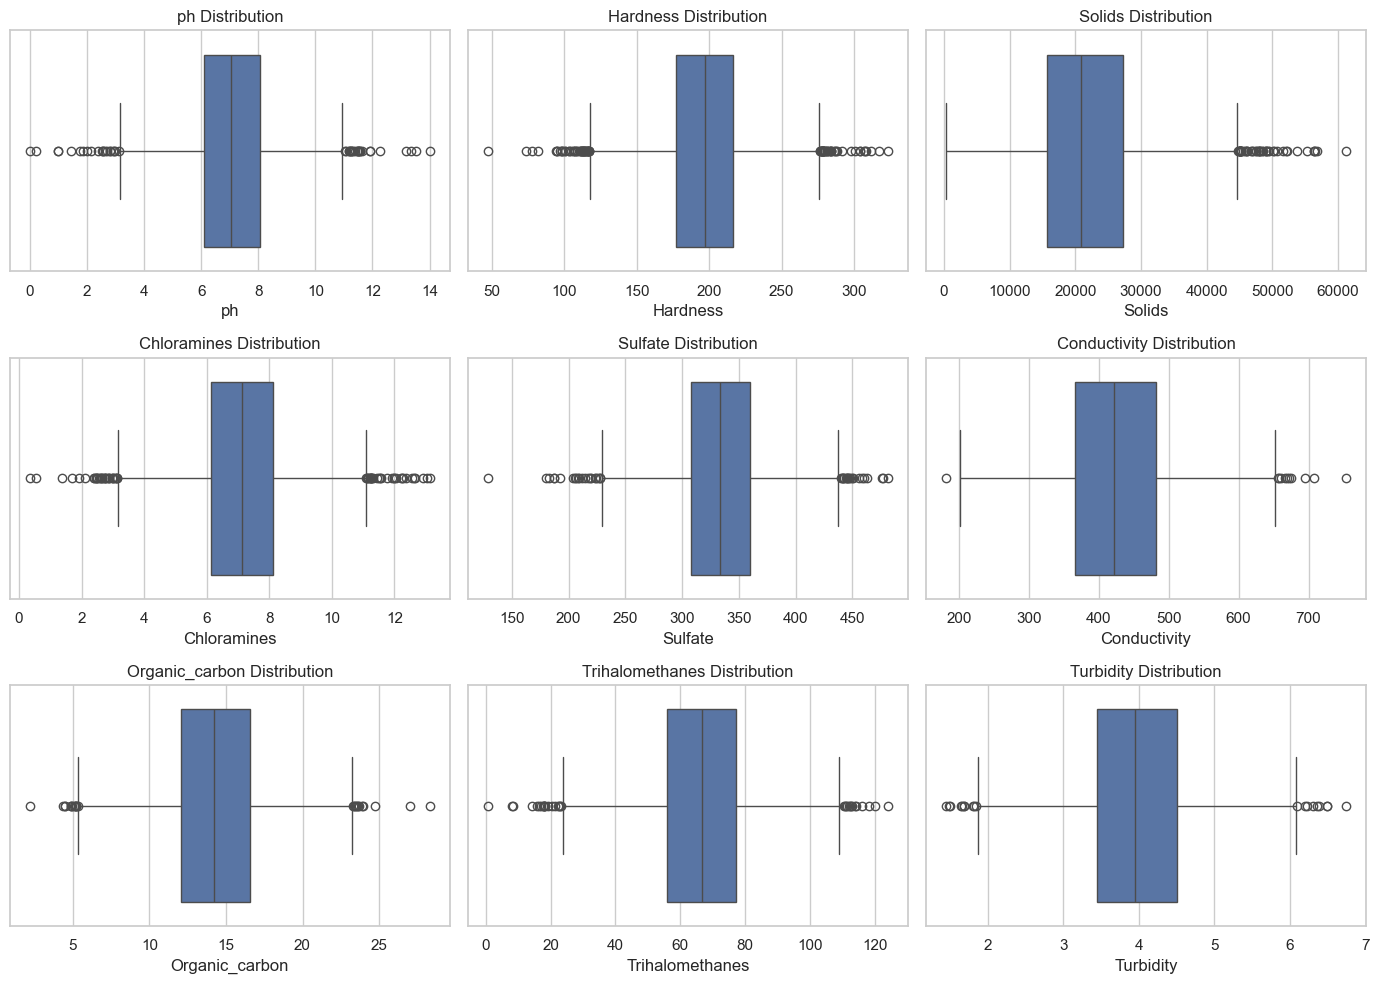

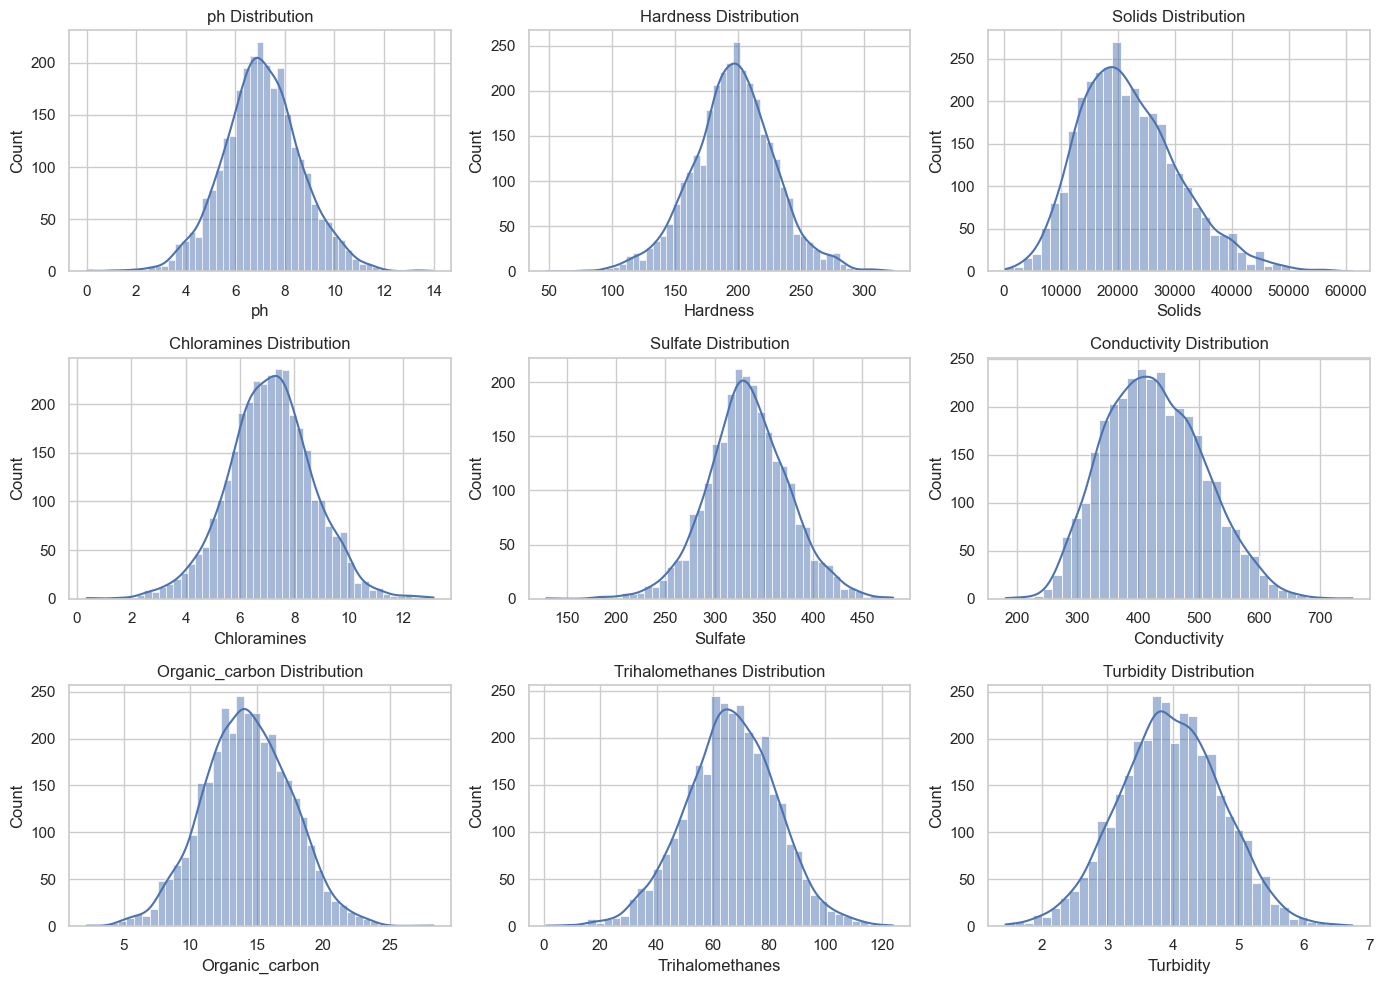

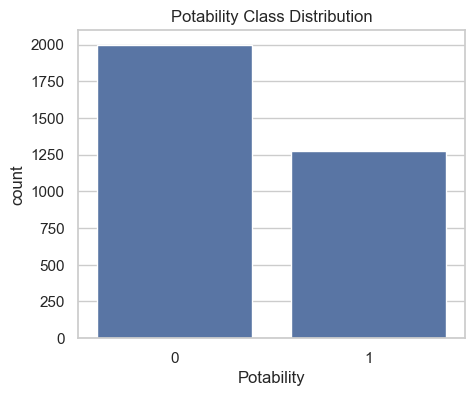

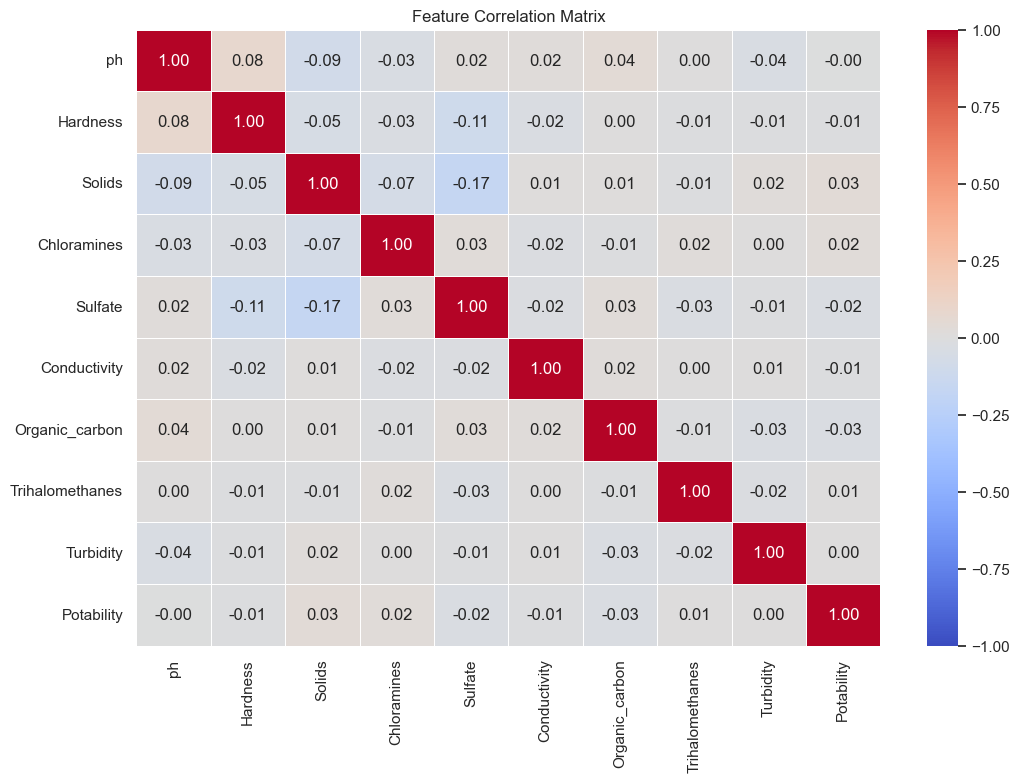

In [3]:

numeric_cols = df.columns.drop('Potability')
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x='Potability', data=df)
plt.title('Potability Class Distribution')
plt.show()

plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()


## 🧹 4. Data Preprocessing & Splitting

In [4]:

y = df['Potability']
X = df.drop('Potability', axis=1)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
preprocessor = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)


## 🔍 5. Feature Selection

In [5]:

selector = SelectKBest(score_func=f_classif, k=5)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)
selected_features = X.columns[selector.get_support()]
print("Selected features based on ANOVA F-test:", list(selected_features))


Selected features based on ANOVA F-test: ['Solids', 'Chloramines', 'Conductivity', 'Organic_carbon', 'Trihalomethanes']


In [6]:
results = []

def eval_grid(name, pipeline, params, X_train, X_test):
    gs = GridSearchCV(pipeline, params, cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    
    preds = gs.predict(X_test)
    
    metrics = {
        'Model': name,
        'Best Params': gs.best_params_,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    }
    results.append(metrics)
    
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, preds))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC Curve + AUC
    if hasattr(gs, "predict_proba"):
        y_prob = gs.predict_proba(X_test)[:, 1]
    else:
        y_prob = gs.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    print(f"{name} AUC: {roc_auc:.4f}")
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.show()

## 🤖 Model: K-Nearest Neighbors (KNN)


KNN Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.89      0.73       600
           1       0.45      0.14      0.22       383

    accuracy                           0.60       983
   macro avg       0.54      0.52      0.47       983
weighted avg       0.56      0.60      0.53       983



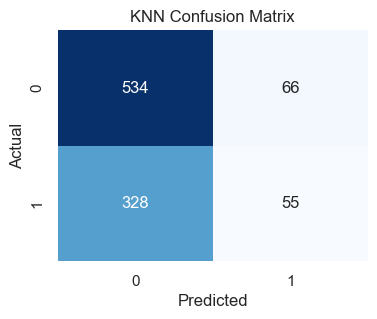

KNN AUC: 0.5220


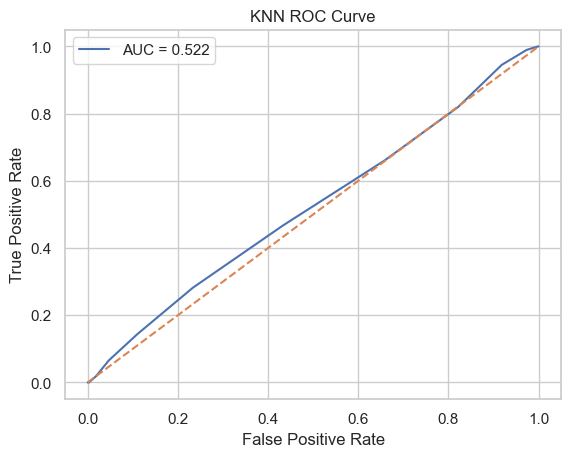

In [7]:
eval_grid('KNN',
    Pipeline([('clf', KNeighborsClassifier())]),
    {'clf__n_neighbors': range(3, 15), 'clf__weights': ['uniform', 'distance'], 'clf__p': [1, 2]},
    X_train_sel, X_test_sel
)

## 🤖 Model: Decision Tree


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.93      0.74       600
           1       0.39      0.07      0.12       383

    accuracy                           0.60       983
   macro avg       0.50      0.50      0.43       983
weighted avg       0.53      0.60      0.50       983



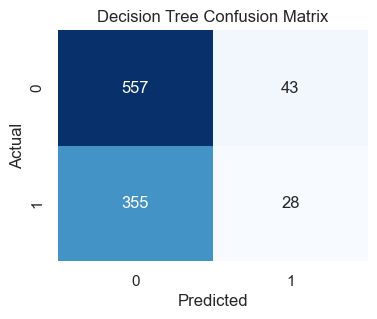

Decision Tree AUC: 0.5303


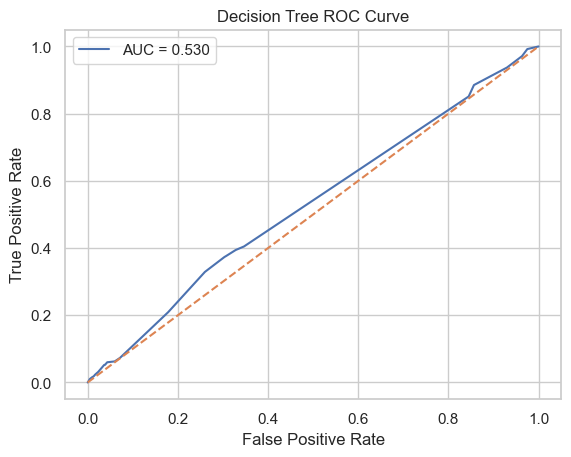

In [8]:
eval_grid('Decision Tree',
    Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    {'clf__max_depth': [None, 5, 10, 15], 'clf__min_samples_split': [2, 5, 10], 'clf__min_samples_leaf': [1, 2, 4]},
    X_train_sel, X_test_sel
)

## 🤖 Model: Support Vector Classifier (SVC)


SVC Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.96      0.75       600
           1       0.52      0.07      0.12       383

    accuracy                           0.61       983
   macro avg       0.57      0.51      0.43       983
weighted avg       0.58      0.61      0.50       983



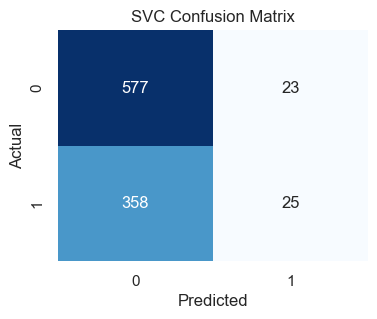

SVC AUC: 0.5349


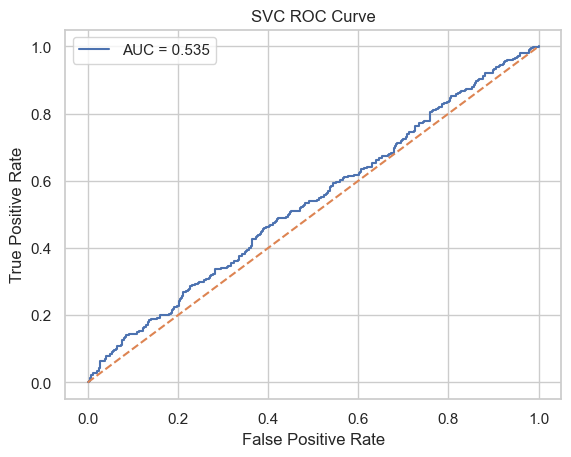

In [9]:
eval_grid('SVC',
    Pipeline([('clf', SVC(random_state=42))]),
    {'clf__C': [0.1, 1, 10, 100], 'clf__kernel': ['linear', 'rbf', 'poly'], 'clf__gamma': ['scale', 'auto']},
    X_train_sel, X_test_sel
)

## 🤖 Model: Random Forest


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       600
           1       0.62      0.31      0.41       383

    accuracy                           0.66       983
   macro avg       0.64      0.59      0.59       983
weighted avg       0.65      0.66      0.62       983



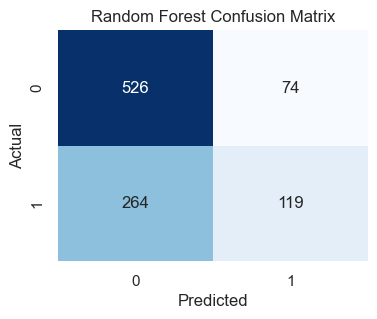

Random Forest AUC: 0.6538


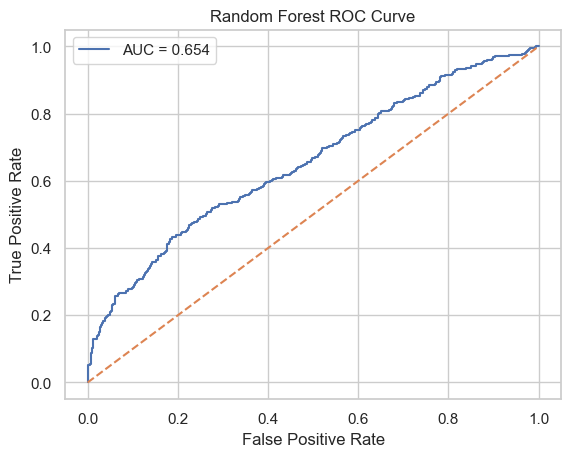

In [10]:
eval_grid('Random Forest',
    Pipeline([('clf', RandomForestClassifier(random_state=42))]),
    {'clf__n_estimators': [100, 200, 300], 'clf__max_depth': [None, 10, 20], 'clf__min_samples_split': [2, 5]},
    X_train, X_test
)

## 📈 6. Results Summary & Comparison

Model Performance Comparison:
           Model  Accuracy  Precision    Recall        F1  \
0            KNN  0.599186   0.454545  0.143603  0.218254   
1  Decision Tree  0.595117   0.394366  0.073107  0.123348   
2            SVC  0.612411   0.520833  0.065274  0.116009   
3  Random Forest  0.656155   0.616580  0.310705  0.413194   

                                         Best Params  
0  {'clf__n_neighbors': 14, 'clf__p': 2, 'clf__we...  
1  {'clf__max_depth': 5, 'clf__min_samples_leaf':...  
2  {'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...  
3  {'clf__max_depth': None, 'clf__min_samples_spl...  


<Figure size 1200x600 with 0 Axes>

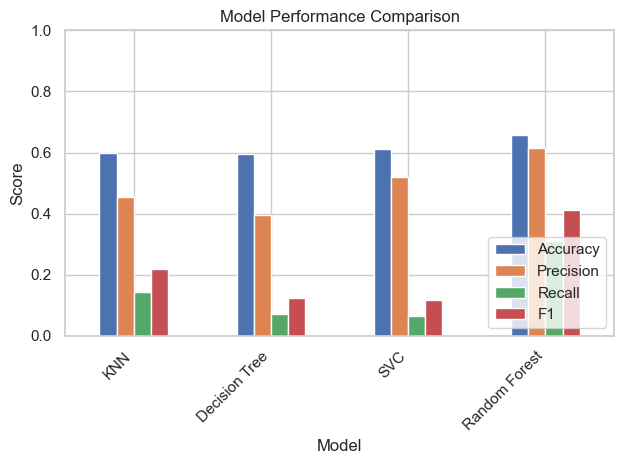

In [11]:

results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'Best Params']])

plt.figure(figsize=(12, 6))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 💾 7. Save Results

In [12]:

results_df.to_csv('water_quality_model_results.csv', index=False)
print("Results saved to 'water_quality_model_results.csv'")


Results saved to 'water_quality_model_results.csv'
